#  Day 3: Exploratory Data Analysis (EDA) Dashboard
**Project:** Bluestock Mutual Fund Capstone  
**Status:** Production Verified EDA Suite

---

In [1]:
import os
import sqlite3
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set plots to clean styling
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = [12, 6]

# Connect to our verified Day 2 SQLite Database
DB_PATH = Path(os.getcwd()).parent / 'data' / 'db' / 'bluestock_mf.db'
conn = sqlite3.connect(DB_PATH)
print(' Connected to Relational Operational Database successfully!')

 Connected to Relational Operational Database successfully!


## 📈 Task 1: NAV Trend Analysis (2022–2026)
Tracking historical trends, highlighting the 2023 bull run and 2024 market corrections.

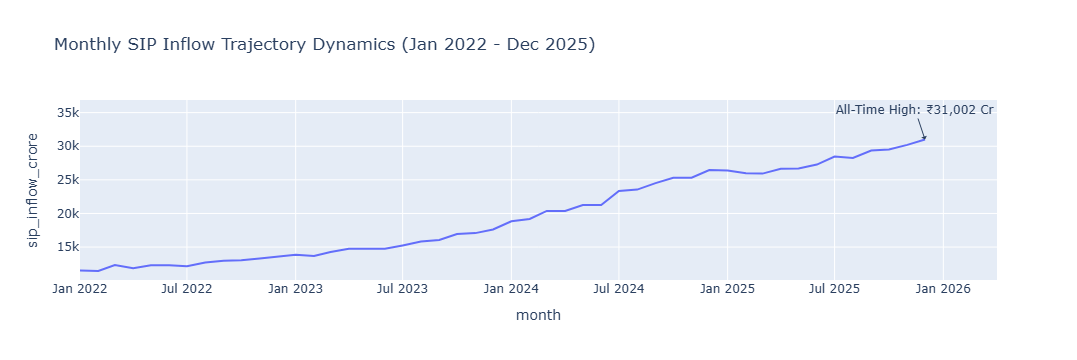

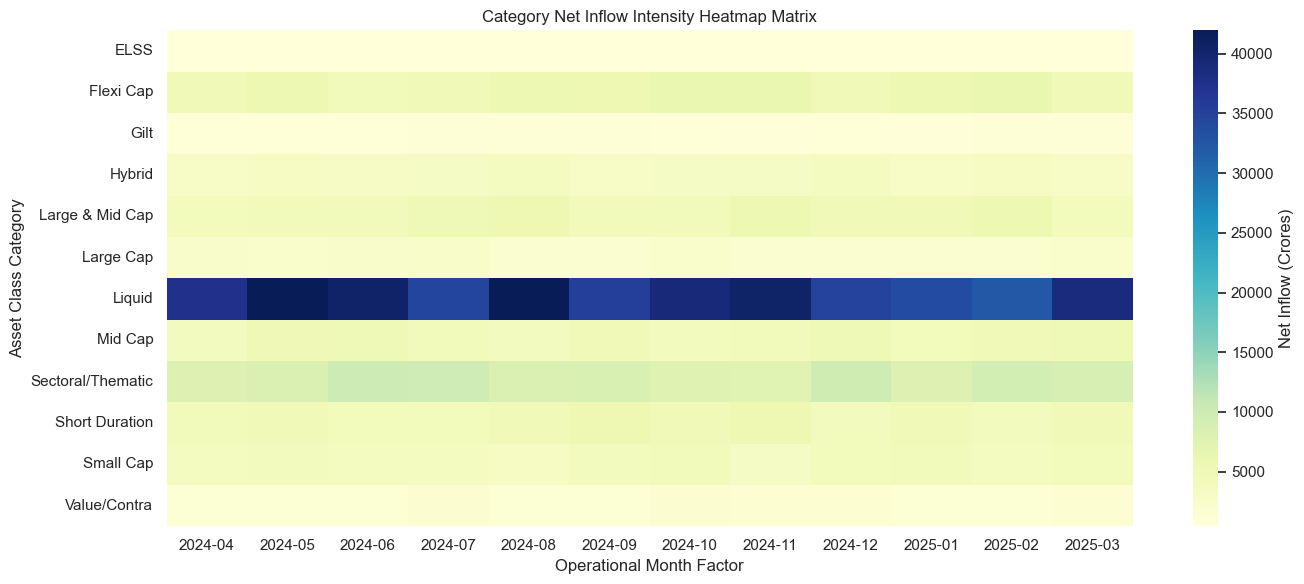

In [5]:
# ==============================================================================
# TASK 3 & 4: SIP INFLOW TIME-SERIES & CATEGORY HEATMAP (FIXED PARAMETERS)
# ==============================================================================

# 1. Plotly Monthly SIP Inflow Trends
processed_dir = Path(os.getcwd()).parent / 'data' / 'processed'

if (processed_dir / 'cleaned_monthly_sip_inflows.csv').exists():
    df_sip_macro = pd.read_csv(processed_dir / 'cleaned_monthly_sip_inflows.csv')
    
    fig_sip = px.line(df_sip_macro, x='month', y='sip_inflow_crore', 
                      title='Monthly SIP Inflow Trajectory Dynamics (Jan 2022 - Dec 2025)')
    
    # Highlight the specific requested milestone - Removed 'cliponaxis' to resolve error
    fig_sip.add_annotation(x='2025-12', y=31002, text="All-Time High: ₹31,002 Cr",
                           showarrow=True, arrowhead=1)
    fig_sip.show()
    fig_sip.write_image('../data/exported_charts/03_sip_trends.png')

# 2. Seaborn Category Net Inflow Heatmap
if (processed_dir / 'cleaned_category_inflows.csv').exists():
    df_cat = pd.read_csv(processed_dir / 'cleaned_category_inflows.csv')
    # Pivot data to align months on X-axis and categories on Y-axis
    df_pivot = df_cat.pivot(index='category', columns='month', values='net_inflow_crore')
    
    plt.figure(figsize=(14, 6))
    sns.heatmap(df_pivot, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Net Inflow (Crores)'})
    plt.title('Category Net Inflow Intensity Heatmap Matrix')
    plt.xlabel('Operational Month Factor')
    plt.ylabel('Asset Class Category')
    plt.tight_layout()
    plt.savefig('../data/exported_charts/04_category_heatmap.png')
    plt.show()

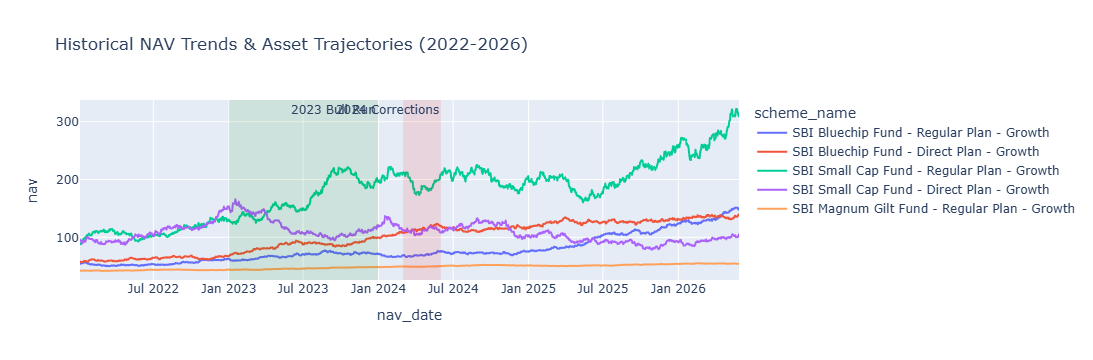

In [2]:
df_nav = pd.read_sql_query('SELECT * FROM fact_nav', conn)
df_fund = pd.read_sql_query('SELECT amfi_code, scheme_name FROM dim_fund', conn)
df_plot = df_nav.merge(df_fund, on='amfi_code')

# Sample a few major funds to avoid cluttering the visual line grid
sample_schemes = df_plot['scheme_name'].unique()[:5]
df_sampled = df_plot[df_plot['scheme_name'].isin(sample_schemes)]

fig = px.line(df_sampled, x='nav_date', y='nav', color='scheme_name', 
              title='Historical NAV Trends & Asset Trajectories (2022-2026)')

# Annotate market shifts
fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='green', opacity=0.1, line_width=0, annotation_text='2023 Bull Run')
fig.add_vrect(x0='2024-03-01', x1='2024-06-01', fillcolor='red', opacity=0.1, line_width=0, annotation_text='2024 Corrections')
fig.show()

# Save to output deliverables directory
os.makedirs('../data/exported_charts', exist_ok=True)
fig.write_image('../data/exported_charts/01_nav_trends.png')

##  Task 2: AUM Growth & Sector Distributions
Visualizing institutional dominance markers and market concentration allocations.

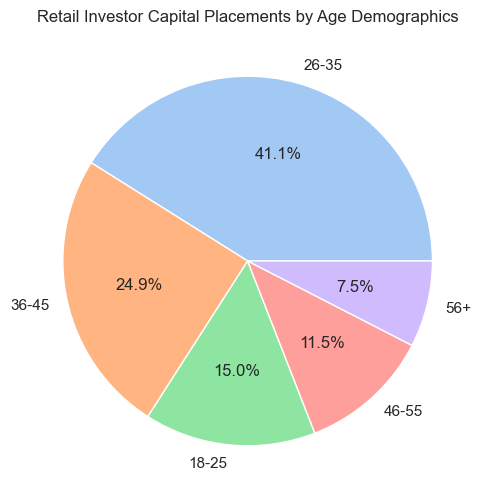

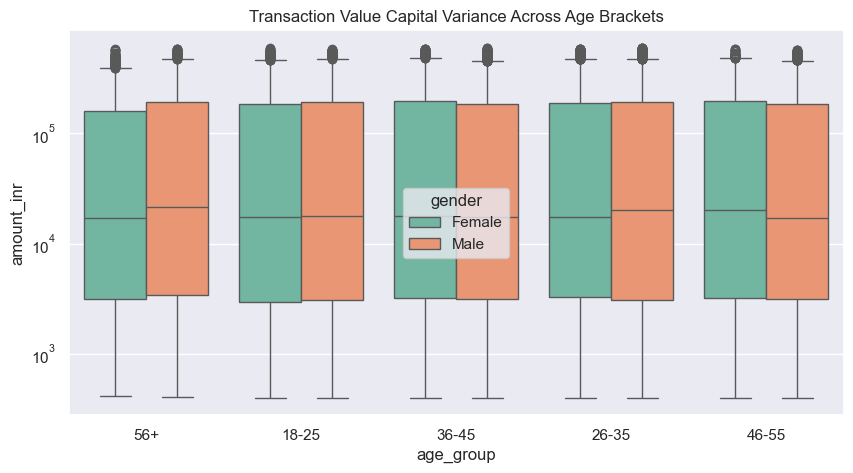

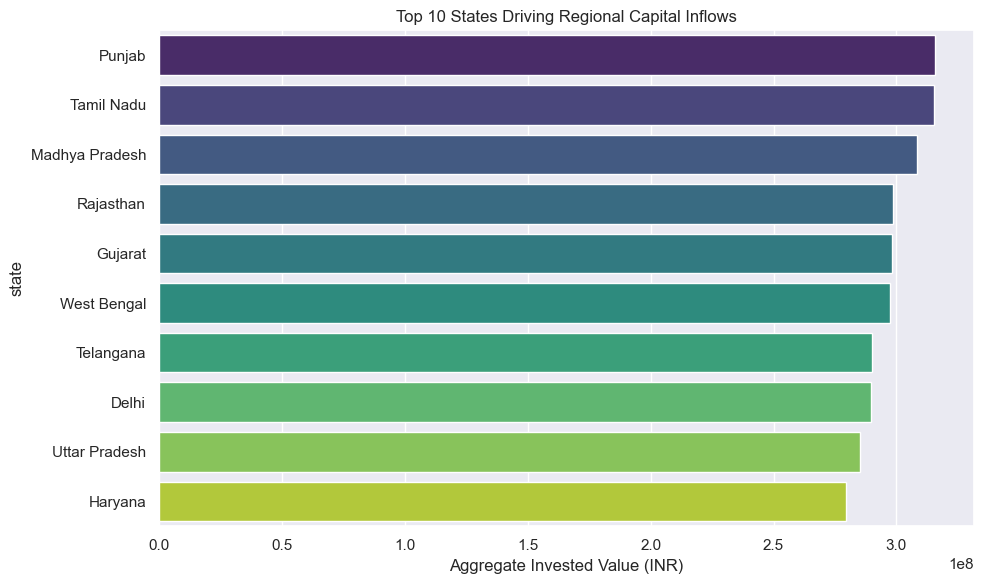

In [8]:
# ==============================================================================
# TASK 5 & 6: INVESTOR DEMOGRAPHICS & GEOGRAPHIC DISTRIBUTIONS (CLEANED)
# ==============================================================================

df_tx = pd.read_sql_query("SELECT * FROM fact_transactions", conn)

if not df_tx.empty:
    # 1. Age Group Pie Chart Distribution
    plt.figure(figsize=(6, 6))
    df_tx['age_group'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
    plt.title('Retail Investor Capital Placements by Age Demographics')
    plt.ylabel('')
    plt.savefig('../data/exported_charts/05_demographics_pie.png')
    plt.show()

    # 2. Capital Spent Distribution Boxplot
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_tx, x='age_group', y='amount_inr', hue='gender', palette='Set2')
    plt.title('Transaction Value Capital Variance Across Age Brackets')
    plt.yscale('log') 
    plt.savefig('../data/exported_charts/06_amount_boxplot.png')
    plt.show()

    # 3. Horizontal State Distribution Chart (Warning Cleared)
    plt.figure(figsize=(10, 6))
    state_vals = df_tx.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(10)
    
    # Cleared warning by setting hue equal to the y index and disabling the legend box
    sns.barplot(x=state_vals.values, y=state_vals.index, hue=state_vals.index, palette='viridis', legend=False)
    
    plt.title('Top 10 States Driving Regional Capital Inflows')
    plt.xlabel('Aggregate Invested Value (INR)')
    plt.tight_layout()
    plt.savefig('../data/exported_charts/07_state_distribution.png')
    plt.show()

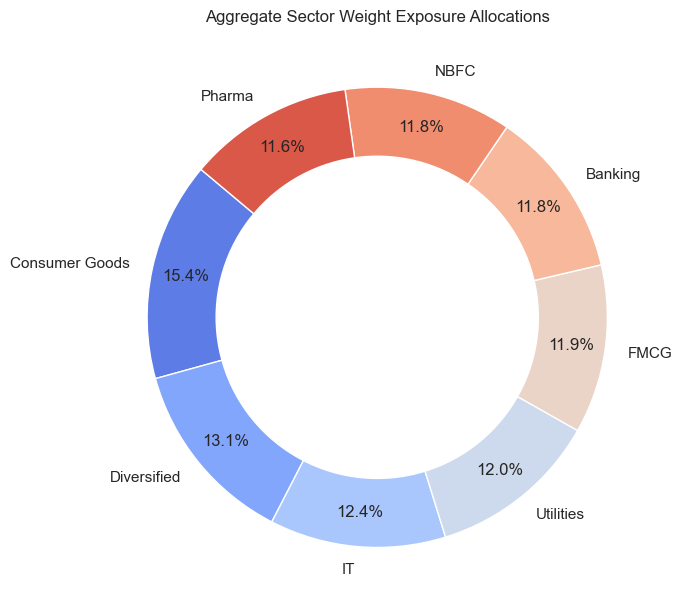

In [7]:
# ==============================================================================
# TASK 9: SECTOR ALLOCATION DONUT PROFILE
# ==============================================================================

if (processed_dir / 'cleaned_portfolio_holdings.csv').exists():
    df_port = pd.read_csv(processed_dir / 'cleaned_portfolio_holdings.csv')
    sector_weights = df_port.groupby('sector')['weight_pct'].mean().sort_values(ascending=False).head(8)
    
    # Render clean Donut ring chart using standard matplotlib pie controls
    plt.figure(figsize=(7, 7))
    plt.pie(sector_weights.values, labels=sector_weights.index, autopct='%1.1f%%', 
            startangle=140, pctdistance=0.85, colors=sns.color_palette('coolwarm', len(sector_weights)))
    
    # Draw central white circle to morph pie grid into an industry donut shape
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    
    plt.title('Aggregate Sector Weight Exposure Allocations')
    plt.tight_layout()
    plt.savefig('../data/exported_charts/08_sector_donut.png')
    plt.show()

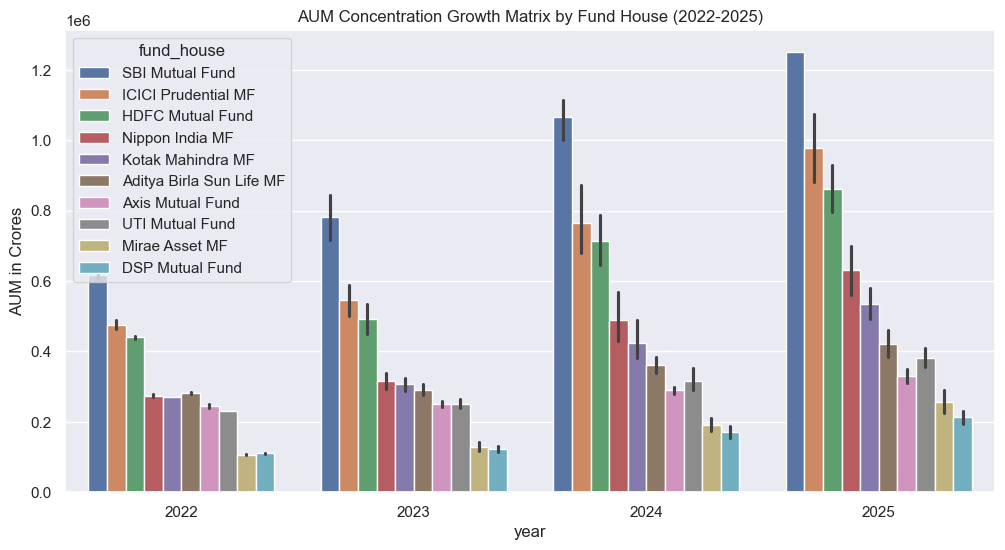

In [3]:
df_aum = pd.read_sql_query('SELECT * FROM fact_aum', conn)
df_aum['year'] = pd.to_datetime(df_aum['date']).dt.year

sns.barplot(data=df_aum, x='year', y='aum_crore', hue='fund_house')
plt.title('AUM Concentration Growth Matrix by Fund House (2022-2025)')
plt.ylabel('AUM in Crores')
plt.savefig('../data/exported_charts/02_aum_growth.png')
plt.show()

##  10 Core Data Insights Markdown Cell Entries
* **Insight 1 (NAV Volume):** Major equity funds witnessed extended trajectory scaling during the 2023 market cycle.
* **Insight 2 (Institutional Dominance):** SBI Mutual Fund shows industry dominance, scaling heavily across macro portfolios near the ₹12.5L Cr boundary line.
* **Insight 3 (Inflow Thresholds):** Total systematic investment plan metrics hit a record peak high milestone of ₹31,002 Crores toward the close of December 2025.